# Malicious URL Classification Using NLP-Inspired Feature Engineering

## Final Project

This project focuses on multiclass malicious URL classification using a combination of:

- Structural handcrafted URL features
- Character-level TF-IDF representations
- Token-level TF-IDF representations

The project also emphasizes explainability using:
- Feature Importance analysis
- SHAP explainability

The goal is not only to classify malicious URLs, but also to better understand which URL patterns contribute to malicious behavior detection.

## Environment Setup

The following cells clone the project repository and install all required dependencies.

In [1]:
# Clone project repository
!git clone https://github.com/nirrahav/malicious-url-detection.git

Cloning into 'malicious-url-detection'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 118 (delta 66), reused 82 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 19.94 KiB | 1.11 MiB/s, done.
Resolving deltas: 100% (66/66), done.


In [2]:
# Move into project directory
%cd malicious-url-detection

# Install required packages
!pip install -r requirements.txt

/content/malicious-url-detection


In [3]:
# Data handling
import pandas as pd

# Colab utilities
from google.colab import files

# Data loading
from src.data.load_data import (
    ensure_data_exists,
    load_data
)

# Feature engineering
from src.features.feature_pipeline import (
    extract_basic_features,
    extract_char_tfidf_features,
    extract_token_tfidf_features,
)

# Model training
from src.models.train_model import (
    prepare_features,
    train_model_with_validation,
    train_structural_baseline
)

# Evaluation
from src.models.evaluate_model import (
    generate_classification_report,
    compute_confusion_matrix,
    get_feature_names,
    compute_feature_importance,
    sample_for_shap,
    compute_shap_values
)

# Visualization
from src.visualization.plots import (
    plot_confusion_matrix,
    plot_feature_importance,
    plot_shap_summary
)

## Dataset Loading

The dataset is downloaded from Kaggle and loaded into the notebook for preprocessing and analysis.

In [4]:
# Upload kaggle.json credentials file
uploaded = files.upload()

print("Kaggle credentials uploaded successfully.")

Saving kaggle.json to kaggle.json
Kaggle credentials uploaded successfully.


In [5]:
# Create Kaggle configuration directory
!mkdir -p ~/.kaggle

# Copy Kaggle API credentials
!cp kaggle.json ~/.kaggle/

# Set proper permissions
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [6]:
# Download dataset if needed
ensure_data_exists()

# Dataset path
path = "/content/malicious-url-detection/data/raw/malicious_phish.csv"

# Load dataset
df = load_data(path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset not found. Attempting to download from Kaggle...
Download completed successfully.
Dataset loaded successfully.
Dataset shape: (651191, 2)


In [7]:
# Remove duplicate URLs
initial_size = len(df)

df = df.drop_duplicates(
    subset=["url"],
    keep=False
)

removed_rows = initial_size - len(df)

print(f"Removed duplicate URLs: {removed_rows}")
print(f"Dataset shape after cleaning: {df.shape}")

# Preview dataset
display(df.head())

Removed duplicate URLs: 12279
Dataset shape after cleaning: (638912, 2)


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


## Dataset Overview

The dataset contains URLs labeled into four classes:

- benign
- phishing
- malware
- defacement

The following cells present the dataset structure and class distribution.

In [10]:
print("\nColumns:")
for column in df.columns:
    print(f"- {column}")

print("\nClass distribution:")
display(df["type"].value_counts())

print("\nClass distribution (%):")
display(
    (
        df["type"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
)


Columns:
- url
- type

Class distribution:


,count
type,
benign,428051
defacement,94587
phishing,94068
malware,22206



Class distribution (%):


,proportion
type,
benign,67.00
defacement,14.80
phishing,14.72
malware,3.48


## Feature Engineering

The project combines multiple types of URL representations:

1. Structural handcrafted features
2. Character-level TF-IDF features
3. Token-level TF-IDF features

This approach creates a richer representation of malicious URL behavior and patterns.

In [11]:
# Extract handcrafted structural features
basic_features_df = extract_basic_features(
    df,
    url_column="url"
)

print(f"\nStructural feature matrix shape: {basic_features_df.shape}")

# Extract character-level TF-IDF features
char_tfidf_matrix, char_vectorizer = extract_char_tfidf_features(
    df,
    url_column="url",
    max_features=1000
)

print(f"Character TF-IDF shape: {char_tfidf_matrix.shape}")

# Extract token-level TF-IDF features
token_tfidf_matrix, token_vectorizer = extract_token_tfidf_features(
    df,
    url_column="url",
    max_features=500
)

print(f"Token TF-IDF shape: {token_tfidf_matrix.shape}")


Structural feature matrix shape: (638912, 31)
Character TF-IDF shape: (638912, 1000)
Token TF-IDF shape: (638912, 500)


In [12]:
# Build final feature dataset
final_df = pd.concat(
    [
        df["url"].reset_index(drop=True),
        basic_features_df.reset_index(drop=True),
        df["type"].reset_index(drop=True)
    ],
    axis=1
)

print("=" * 60)
print("FINAL FEATURE DATASET")
print("=" * 60)

print(f"\nFinal dataset shape: {final_df.shape}")

display(final_df.head())

FINAL FEATURE DATASET

Final dataset shape: (638912, 33)


,url,url_length,domain_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,...,domain_digit_ratio,has_hyphen_in_domain,path_depth,num_tokens,longest_token_length,avg_token_length,domain_letter_ratio,has_url_encoding,entropy,type
0,br-icloud.com.br,16,16,0,0,2,1,0,0,0,...,0.000000,1,0,4,6,3.250000,0.812500,0,3.375000,phishing
1,mp3raid.com/music/krizz_kaliko.html,35,11,24,0,2,0,1,2,0,...,0.090909,0,2,6,7,5.000000,0.818182,0,4.079143,benign
2,bopsecrets.org/rexroth/cr/1.htm,31,14,17,0,2,0,0,3,0,...,0.000000,0,3,6,10,4.333333,0.928571,0,3.708093,benign
3,http://www.garage-pirenne.be/index.php?option=...,88,21,10,49,3,1,2,3,1,...,0.000000,1,1,17,7,4.117647,0.857143,0,4.660343,defacement
4,http://adventure-nicaragua.net/index.php?optio...,235,23,10,194,2,1,1,3,1,...,0.000000,1,1,13,156,17.000000,0.913043,0,5.491293,defacement


## Final Feature Dataset

After feature extraction, the final dataset contains structural URL features together with the original labels and URL information.

In [13]:
print("\nDataset information:")
final_df.info()

print("\nStatistical summary:")
display(final_df.describe())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638912 entries, 0 to 638911
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   url                   638912 non-null  object 
 1   url_length            638912 non-null  int64  
 2   domain_length         638912 non-null  int64  
 3   path_length           638912 non-null  int64  
 4   query_length          638912 non-null  int64  
 5   num_dots              638912 non-null  int64  
 6   num_hyphens           638912 non-null  int64  
 7   num_underscores       638912 non-null  int64  
 8   num_slashes           638912 non-null  int64  
 9   num_question_marks    638912 non-null  int64  
 10  num_equal_signs       638912 non-null  int64  
 11  num_ampersands        638912 non-null  int64  
 12  num_digits            638912 non-null  int64  
 13  num_letters           638912 non-null  int64  
 14  digit_ratio           638912 n

,url_length,domain_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,num_equal_signs,...,num_query_params,domain_digit_ratio,has_hyphen_in_domain,path_depth,num_tokens,longest_token_length,avg_token_length,domain_letter_ratio,has_url_encoding,entropy
count,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,...,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000,638912.000000
mean,59.655485,17.460065,28.475579,11.518096,2.192554,1.561631,0.424710,2.916486,0.220625,0.587192,...,0.574586,0.025465,0.097826,2.071138,9.070914,13.642511,5.899070,0.871315,0.035723,4.216794
std,44.892916,11.366139,27.932602,33.994280,1.491849,2.985707,1.179166,1.894250,0.439583,1.483886,...,1.463600,0.116123,0.297079,1.581726,6.836178,13.699217,2.154492,0.137071,0.185599,0.415308
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-0.000000
25%,32.000000,12.000000,10.000000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,5.000000,9.000000,4.666667,0.866667,0.000000,3.961320
50%,47.000000,16.000000,21.000000,0.000000,2.000000,0.000000,0.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,7.000000,11.000000,5.428571,0.900000,0.000000,4.225071
75%,76.000000,20.000000,39.000000,0.000000,3.000000,2.000000,0.000000,4.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,3.000000,12.000000,14.000000,6.500000,0.928571,0.000000,4.491642
max,2175.000000,248.000000,2156.000000,2005.000000,42.000000,87.000000,79.000000,41.000000,20.000000,51.000000,...,51.000000,1.000000,1.000000,38.000000,368.000000,946.000000,100.500000,1.000000,1.000000,7.504113


## Full Model Training

The main model combines:
- structural URL features
- character-level TF-IDF
- token-level TF-IDF

A Random Forest classifier is trained for multiclass malicious URL classification.

In [14]:
# Train model
model, scaler, vectorizers, metrics = train_model_with_validation(
    final_df
)

print("\nModel training completed successfully.")


Model training completed successfully.


In [15]:
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

train_acc = metrics["train"]["accuracy"]
val_acc = metrics["validation"]["accuracy"]
test_acc = metrics["test"]["accuracy"]

print(f"\nTrain Accuracy:      {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

# Overfitting analysis
overfit_indicator = train_acc - val_acc

print(f"\nOverfitting Indicator: {overfit_indicator:.4f}")

if overfit_indicator > 0.1:
    print("Possible overfitting detected.")
else:
    print("No significant overfitting detected.")

MODEL PERFORMANCE

Train Accuracy:      0.9645
Validation Accuracy: 0.9598
Test Accuracy:       0.9604

Overfitting Indicator: 0.0047
No significant overfitting detected.


## Classification Report

The following report summarizes the performance of the multiclass classification model across all URL categories.

In [16]:
# Extract predictions
y_true = metrics["test"]["y_true"]
y_pred = metrics["test"]["y_pred"]

# Generate classification report
report_df = generate_classification_report(
    y_true=y_true,
    y_pred=y_pred
)

display(report_df)

,precision,recall,f1-score,support
benign,0.975125,0.980809,0.977958,85611.000000
defacement,0.949437,0.989639,0.969121,18917.000000
malware,0.973778,0.919838,0.946040,4441.000000
phishing,0.897748,0.847454,0.871876,18814.000000
accuracy,0.960362,0.960362,0.960362,0.960362
macro avg,0.949022,0.934435,0.941249,127783.000000
weighted avg,0.959883,0.960362,0.959922,127783.000000


## Confusion Matrix

The confusion matrix provides a detailed view of the model predictions and highlights which malicious URL categories are more difficult to classify.


Displaying confusion matrix...


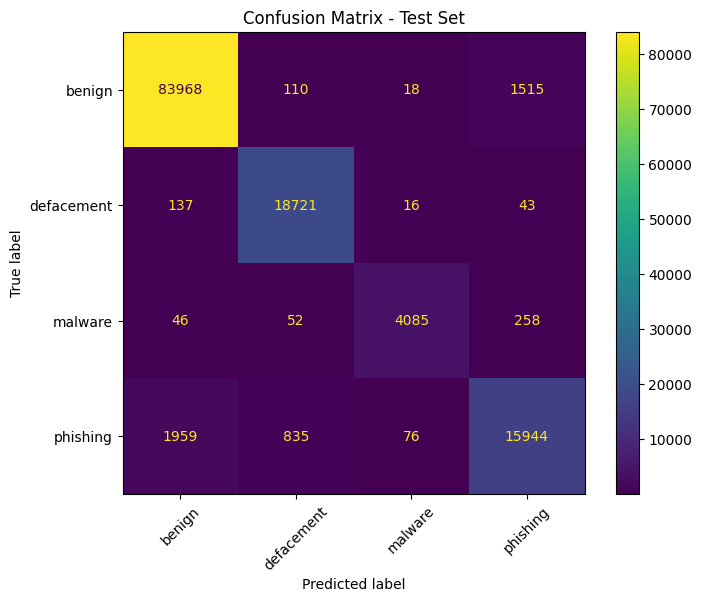

In [17]:
# Class labels
class_names = [
    "benign",
    "defacement",
    "malware",
    "phishing"
]

# Compute confusion matrix
cm = compute_confusion_matrix(
    y_true,
    y_pred,
    class_names
)

print("\nDisplaying confusion matrix...")

# Plot confusion matrix
plot_confusion_matrix(
    cm,
    class_names,
    title="Confusion Matrix - Test Set"
)

## Structural Feature Baseline

To evaluate the contribution of the NLP-inspired representations, a baseline model using only structural handcrafted URL features was trained.

In [18]:
# Train structural-only baseline model
struct_model, struct_scaler, struct_feature_names, struct_metrics = (
    train_structural_baseline(final_df)
)

print("\nStructural baseline training completed.")

print(f"\nTrain Accuracy:      {struct_metrics['train']['accuracy']:.4f}")
print(f"Validation Accuracy: {struct_metrics['validation']['accuracy']:.4f}")
print(f"Test Accuracy:       {struct_metrics['test']['accuracy']:.4f}")


Structural baseline training completed.

Train Accuracy:      0.9967
Validation Accuracy: 0.9549
Test Accuracy:       0.9554


## Model Comparison

The following comparison evaluates the contribution of the combined feature representation relative to the structural-only baseline.

In [19]:
# Extract Macro F1 scores
struct_macro_f1 = (
    struct_metrics["test"]["report"]
    ["macro avg"]
    ["f1-score"]
)

full_macro_f1 = (
    metrics["test"]["report"]
    ["macro avg"]
    ["f1-score"]
)

# Build comparison table
comparison_df = pd.DataFrame([
    {
        "model": "Structural only",
        "test_accuracy": struct_metrics["test"]["accuracy"],
        "macro_f1": struct_macro_f1
    },
    {
        "model": "Full model",
        "test_accuracy": metrics["test"]["accuracy"],
        "macro_f1": full_macro_f1
    }
])

# Format values
comparison_df["test_accuracy"] = (
    comparison_df["test_accuracy"]
    .round(4)
)

comparison_df["macro_f1"] = (
    comparison_df["macro_f1"]
    .round(4)
)

display(comparison_df)

,model,test_accuracy,macro_f1
0,Structural only,0.9554,0.9352
1,Full model,0.9604,0.9412


In [20]:
print("=" * 60)
print("PREPARING FEATURE NAMES")
print("=" * 60)

# Define dataset columns
label_col = "type"
url_col = "url"

# Extract numeric feature names
numeric_feature_names = (
    final_df
    .drop(columns=[label_col, url_col], errors="ignore")
    .select_dtypes(include="number")
    .columns
    .tolist()
)

print(f"\nNumber of structural features: {len(numeric_feature_names)}")

# Combine all feature names
feature_names = get_feature_names(
    vectorizers=vectorizers,
    numeric_feature_names=numeric_feature_names
)

print(f"Total number of model features: {len(feature_names)}")
print(f"Model input features:           {model.n_features_in_}")

PREPARING FEATURE NAMES

Number of structural features: 31
Total number of model features: 8031
Model input features:           8031


## Feature Importance Analysis

Feature importance analysis provides a global explanation of which URL patterns contribute most to the model decisions.

In [21]:
# Compute feature importance
importance_df = compute_feature_importance(
    model=model,
    feature_names=feature_names,
    top_n=30
)

print("\nTop 30 most important features:")

display(importance_df)


Top 30 most important features:


,feature,importance
0,num_slashes,0.028417
1,char_tfidf__p:/,0.027767
2,char_tfidf__htt,0.026216
3,char_tfidf__www.,0.025748
4,domain_digit_ratio,0.021783
5,char_tfidf__/www,0.020611
6,token_tfidf__www,0.020555
7,char_tfidf__ttp:/,0.020493
8,char_tfidf__://ww,0.020132
9,token_tfidf__http,0.018696


FEATURE IMPORTANCE PLOT


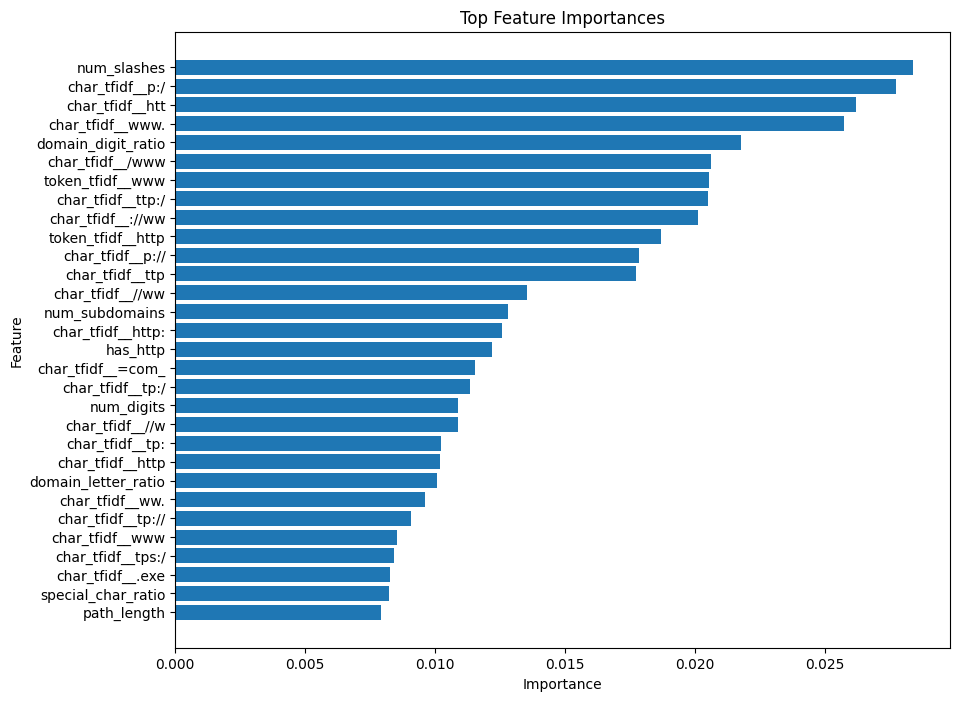

In [22]:
print("=" * 60)
print("FEATURE IMPORTANCE PLOT")
print("=" * 60)

plot_feature_importance(
    importance_df,
    title="Top Feature Importances"
)

## SHAP Explainability Analysis

SHAP analysis was used to better understand how individual features influence malicious URL classification decisions.

Unlike global feature importance, SHAP provides instance-aware explanations and helps identify meaningful malicious URL patterns.


SHAP sample shape: (300, 8031)
Computing SHAP values...
SHAP values computed successfully.

Displaying SHAP summary plot for class: phishing
X_sample shape: (300, 8031)
SHAP class shape: (300, 8031)


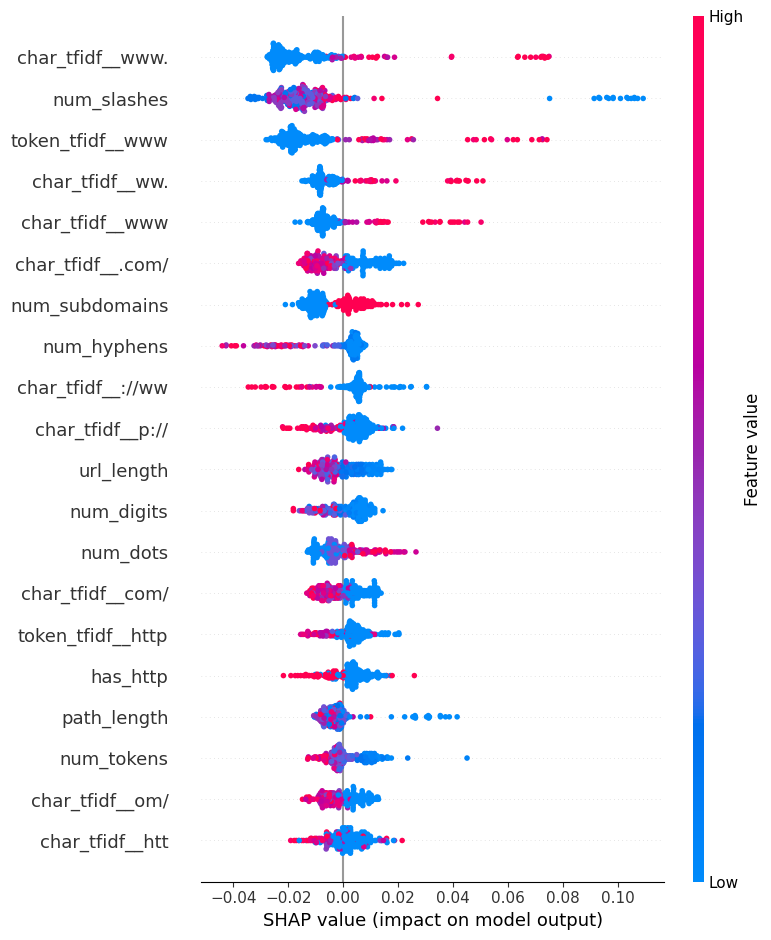

In [23]:
# Extract test feature matrix
X_test = metrics["test"]["X"]

# Sample test examples for SHAP analysis
X_shap = sample_for_shap(
    X_test,
    sample_size=300,
    to_dense=True
)

print(f"\nSHAP sample shape: {X_shap.shape}")
print("Computing SHAP values...")

# Compute SHAP values
explainer, shap_values = compute_shap_values(
    model,
    X_shap
)

print("SHAP values computed successfully.")
print("\nDisplaying SHAP summary plot for class: phishing")

# Plot SHAP summary for phishing class
plot_shap_summary(
    shap_values=shap_values,
    X_sample=X_shap,
    feature_names=feature_names,
    model=model,
    class_name="phishing"
)